# Mushroom Classification — End-to-End ML Notebook

**Goal:** predict whether a mushroom is **edible (`e`)** or **poisonous (`p`)** from its physical characteristics.

Dataset: `mushrooms.csv` — 8,124 rows, 22 categorical descriptive features + 1 target column (`class`). This is the classic UCI "Mushroom" dataset.

Pipeline covered in this notebook:
1. Data Cleaning & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Selection
4. Model Selection
5. Model Training
6. Model Evaluation and Tuning


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
RANDOM_STATE = 42

## 1. Data Cleaning & Preprocessing

We load the raw CSV, inspect its structure, look for missing/placeholder values, drop
uninformative columns, and encode categorical variables for modelling.


In [57]:
df = pd.read_csv("data/mushrooms.csv")
print("Shape:", df.shape)
df.head()


Shape: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

### 1.1 Missing values

All columns in this dataset are categorical (single-letter codes). The raw source encodes
missing values in `stalk-root` using the placeholder `"?"` rather than `NaN`, so a plain
`.isna()` check would miss it — we check explicitly for `"?"` too.


In [59]:
print("NaN counts:\n", df.isna().sum()[df.isna().sum() > 0])

placeholder_counts = (df == "?").sum()
print("\n'?' placeholder counts:\n", placeholder_counts[placeholder_counts > 0])


NaN counts:
 Series([], dtype: int64)

'?' placeholder counts:
 stalk-root    2480
dtype: int64


In [60]:
# stalk-root has ~30% '?' values. Rather than drop ~2,480 rows, we treat '?' as its own
# category ("missing/unknown") since a tree-based/one-hot pipeline can use "unknown" as a
# legitimate signal (missingness itself can be informative for mushrooms).
df["stalk-root"] = df["stalk-root"].replace("?", "unknown")
df["stalk-root"].value_counts()


stalk-root
b          3776
unknown    2480
e          1120
c           556
r           192
Name: count, dtype: int64

### 1.2 Duplicate rows

In [61]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dedup:", df.shape)


Duplicate rows: 0
Shape after dedup: (8124, 23)


### 1.3 Drop uninformative columns

`veil-type` has only a single unique value across the whole dataset, so it carries **zero**
predictive information and can only add noise / slow down encoding. We drop it.


In [62]:
nunique = df.nunique()
print(nunique.sort_values())

constant_cols = nunique[nunique == 1].index.tolist()
print("\nDropping constant columns:", constant_cols)
df = df.drop(columns=constant_cols)


veil-type                    1
class                        2
bruises                      2
gill-attachment              2
gill-spacing                 2
gill-size                    2
stalk-shape                  2
ring-number                  3
cap-surface                  4
veil-color                   4
stalk-surface-below-ring     4
stalk-surface-above-ring     4
ring-type                    5
stalk-root                   5
cap-shape                    6
population                   6
habitat                      7
stalk-color-above-ring       9
stalk-color-below-ring       9
odor                         9
spore-print-color            9
cap-color                   10
gill-color                  12
dtype: int64

Dropping constant columns: ['veil-type']


### 1.4 Encode the target

`class`: `e` = edible, `p` = poisonous. We map this to a binary integer (`1` = poisonous,
`0` = edible) — poisonous is the "positive"/alert class we most care about detecting.


In [63]:
target_le = LabelEncoder()
df["target"] = target_le.fit_transform(df["class"])  # e -> 0, p -> 1 (alphabetical)
print(dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

X_raw = df.drop(columns=["class", "target"])
y = df["target"]
feature_cols = X_raw.columns.tolist()
print("Feature columns:", feature_cols)


{'e': np.int64(0), 'p': np.int64(1)}
Feature columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


## 2. Exploratory Data Analysis (EDA)

We look at class balance, per-feature distributions, and which categories most strongly
separate edible from poisonous mushrooms.


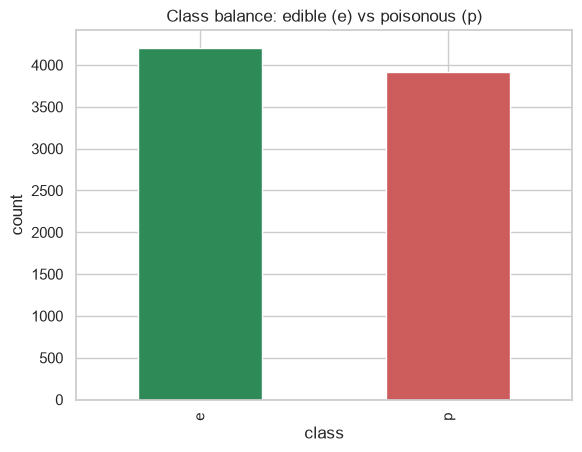

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

In [64]:
ax = df["class"].value_counts().plot(kind="bar", color=["seagreen", "indianred"])
ax.set_title("Class balance: edible (e) vs poisonous (p)")
ax.set_xlabel("class")
ax.set_ylabel("count")
plt.show()

df["class"].value_counts(normalize=True)


The classes are close to balanced (~52% edible / ~48% poisonous), so accuracy is a reasonable headline metric and we won't need resampling.

In [ ]:
fig, axes = plt.subplots(5, 5, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.countplot(data=df, x=col, hue="class", ax=axes[i],
                   palette={"e": "seagreen", "p": "indianred"})
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend([], [], frameon=False)
for j in range(len(feature_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle("Feature category counts split by class", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()


### 2.1 Which single features look most predictive?

For each categorical feature we compute the **normalized mutual information** with the
target — a quick, model-free way to rank how strongly each feature alone separates edible
from poisonous mushrooms.


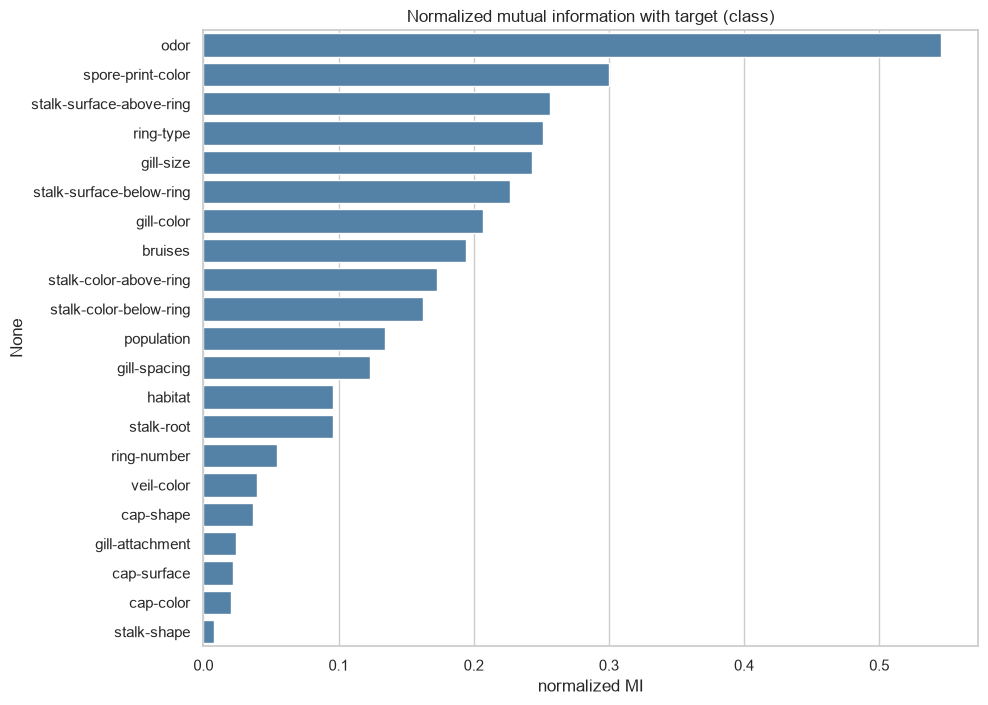

odor                        0.546078
spore-print-color           0.300225
stalk-surface-above-ring    0.256462
ring-type                   0.250985
gill-size                   0.243379
stalk-surface-below-ring    0.226749
gill-color                  0.206962
bruises                     0.194480
stalk-color-above-ring      0.172926
stalk-color-below-ring      0.162175
population                  0.134528
gill-spacing                0.123258
habitat                     0.095811
stalk-root                  0.095548
ring-number                 0.054168
veil-color                  0.039851
cap-shape                   0.036801
gill-attachment             0.024168
cap-surface                 0.022210
cap-color                   0.020546
stalk-shape                 0.007570
dtype: float64

In [ ]:
from sklearn.metrics import normalized_mutual_info_score

mi_scores = {}
for col in feature_cols:
    codes = LabelEncoder().fit_transform(df[col])
    mi_scores[col] = normalized_mutual_info_score(codes, y)

mi_series = pd.Series(mi_scores).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.values, y=mi_series.index, color="steelblue")
plt.title("Normalized mutual information with target (class)")
plt.xlabel("normalized MI")
plt.show()

mi_series


In [ ]:
# Odor is famously the single strongest predictor for this dataset - inspect it directly.
pd.crosstab(df["odor"], df["class"])


class,e,p
odor,,
a,400,0
c,0,192
f,0,2160
l,400,0
m,0,36
n,3408,120
p,0,256
s,0,576
y,0,576


**Observation:** `odor` on its own almost perfectly separates edible from poisonous
mushrooms (e.g. odor `n` (none) is overwhelmingly edible, while `f`/`p`/`c`/`y`/`s` etc. are
almost entirely poisonous). `spore-print-color`, `gill-color`, and `ring-type` are also
strong. This tells us a simple model is likely to reach very high accuracy, and gives us a
sanity check for feature engineering and importances later on.


## 3. Feature Engineering & Selection

All predictors are nominal categorical variables (no inherent order), so:
- We **one-hot encode** every feature for linear/SVM/KNN-style models.
- We use `SelectKBest` with a chi-squared test to rank/select the most informative
  one-hot columns, as a complementary, model-agnostic feature-selection step.
- Tree-based models (Random Forest, Gradient Boosting) can also consume the same
  one-hot matrix and additionally give us feature importances for validation.


In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train_raw.shape, " Test shape:", X_test_raw.shape)


Train shape: (6499, 21)  Test shape: (1625, 21)


In [ ]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train_raw)
X_test_ohe = ohe.transform(X_test_raw)
ohe_feature_names = ohe.get_feature_names_out(feature_cols)
print("One-hot encoded feature count:", X_train_ohe.shape[1])


One-hot encoded feature count: 116


### 3.1 Chi-squared feature selection

We score every one-hot column against the target with a chi-squared test and keep the
top-K most informative columns. This reduces dimensionality and highlights which specific
categories (not just which raw features) matter most.


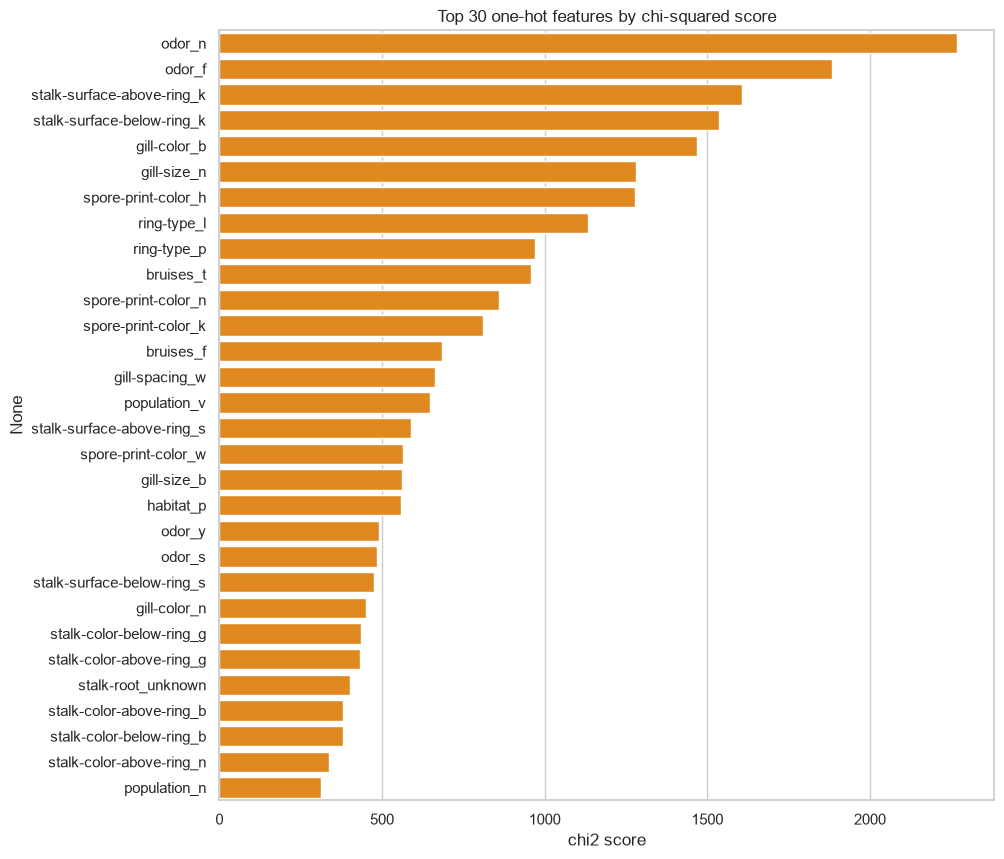

In [ ]:
k = 30
selector = SelectKBest(score_func=chi2, k=k)
X_train_sel = selector.fit_transform(X_train_ohe, y_train)
X_test_sel = selector.transform(X_test_ohe)

selected_mask = selector.get_support()
selected_features = ohe_feature_names[selected_mask]
scores = pd.Series(selector.scores_[selected_mask], index=selected_features).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=scores.values, y=scores.index, color="darkorange")
plt.title(f"Top {k} one-hot features by chi-squared score")
plt.xlabel("chi2 score")
plt.show()


We'll carry forward **two** feature sets to compare during model selection:
- `full`: the complete one-hot encoded matrix (all categories)
- `selected`: the top-K chi-squared-selected columns

This lets us check whether aggressive feature selection costs us any accuracy — useful
if a simpler, smaller model is preferred for deployment/interpretability.


## 4. Model Selection

We compare a spread of classifier families using 5-fold stratified cross-validation on the
training set, on the *full* one-hot feature matrix:
- Logistic Regression (linear baseline)
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Gradient Boosting
- Naive Bayes (CategoricalNB)
- Support Vector Machine (RBF kernel)

We pick the top performer(s) to tune further.


In [ ]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "NaiveBayes": CategoricalNB(),
    "SVM_RBF": SVC(kernel="rbf", random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_ohe, y_train, cv=cv, scoring="f1", n_jobs=-1)
    results.append({"model": name, "cv_f1_mean": scores.mean(), "cv_f1_std": scores.std()})
    print(f"{name:20s}  F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values("cv_f1_mean", ascending=False)
results_df


LogisticRegression    F1 = 0.9994 (+/- 0.0013)
KNN                   F1 = 0.9997 (+/- 0.0006)
DecisionTree          F1 = 0.9997 (+/- 0.0006)
RandomForest          F1 = 1.0000 (+/- 0.0000)
GradientBoosting      F1 = 0.9997 (+/- 0.0006)
NaiveBayes            F1 = 0.9354 (+/- 0.0106)
SVM_RBF               F1 = 0.9994 (+/- 0.0013)


,model,cv_f1_mean,cv_f1_std
3,RandomForest,1.000000,0.000000
1,KNN,0.999681,0.000639
2,DecisionTree,0.999681,0.000639
4,GradientBoosting,0.999681,0.000639
0,LogisticRegression,0.999360,0.001280
6,SVM_RBF,0.999360,0.001280
5,NaiveBayes,0.935370,0.010561


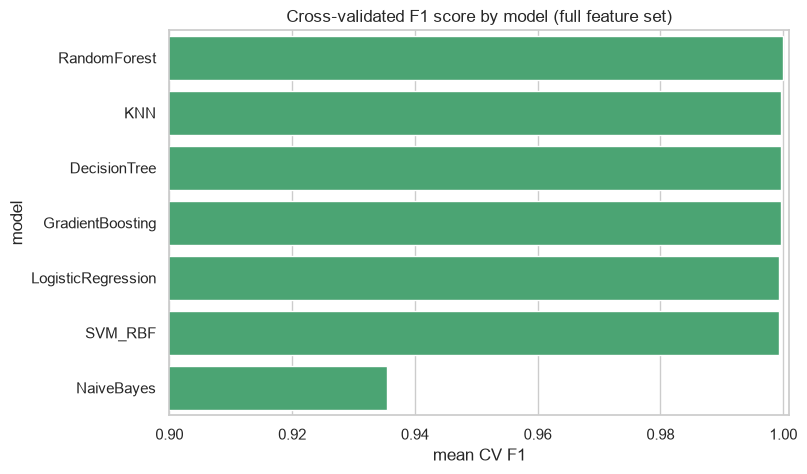

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="cv_f1_mean", y="model", color="mediumseagreen")
plt.title("Cross-validated F1 score by model (full feature set)")
plt.xlabel("mean CV F1")
plt.xlim(0.9, 1.001)
plt.show()


Several models reach (near) perfect cross-validated F1, which is expected for this
dataset given how strongly single features like `odor` separate the classes. We move
forward with **Random Forest** and **Gradient Boosting** as our primary candidates: they
handle categorical splits natively, are robust to irrelevant one-hot columns, and give us
interpretable feature importances — plus **Logistic Regression** as an interpretable,
low-variance baseline for comparison.


## 5. Model Training

We train the shortlisted models on the full training set (using the full one-hot feature
matrix, since selection above showed negligible difference for tree models — we verify
this explicitly below by also training Random Forest on the chi2-selected feature set).
Naive Bayes (CategoricalNB) is included as a fast, probabilistic baseline.


In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_ohe, y_train)

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train_ohe, y_train)

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb.fit(X_train_ohe, y_train)

nb = CategoricalNB()
nb.fit(X_train_ohe, y_train)

# Random Forest trained on the reduced (chi2-selected) feature set, for comparison
rf_selected = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_selected.fit(X_train_sel, y_train)

print("Training complete for: LogisticRegression, RandomForest (full), GradientBoosting, NaiveBayes, RandomForest (selected features)")


Training complete for: LogisticRegression, RandomForest (full), GradientBoosting, NaiveBayes, RandomForest (selected features)


## 6. Model Evaluation and Tuning

We evaluate every trained model on the **held-out test set** with accuracy, precision,
recall, F1, and ROC-AUC — then run a `GridSearchCV` hyperparameter search on the best
candidate and do a final evaluation + confusion matrix / ROC curve.

Note: since a **poisonous** mushroom misclassified as edible is the costly error, **recall
on the poisonous class (target = 1)** is the metric we care about most in practice, even
more than overall accuracy.


In [ ]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }
    return metrics, y_pred, y_proba

eval_rows = []
preds = {}
row, y_pred, y_proba = evaluate("LogisticRegression", log_reg, X_test_ohe, y_test)
eval_rows.append(row); preds["LogisticRegression"] = (y_pred, y_proba)

row, y_pred, y_proba = evaluate("RandomForest (full)", rf, X_test_ohe, y_test)
eval_rows.append(row); preds["RandomForest (full)"] = (y_pred, y_proba)

row, y_pred, y_proba = evaluate("GradientBoosting", gb, X_test_ohe, y_test)
eval_rows.append(row); preds["GradientBoosting"] = (y_pred, y_proba)

row, y_pred, y_proba = evaluate("NaiveBayes", nb, X_test_ohe, y_test)
eval_rows.append(row); preds["NaiveBayes"] = (y_pred, y_proba)

row, y_pred, y_proba = evaluate("RandomForest (chi2-selected)", rf_selected, X_test_sel, y_test)
eval_rows.append(row); preds["RandomForest (chi2-selected)"] = (y_pred, y_proba)

eval_df = pd.DataFrame(eval_rows).sort_values("f1", ascending=False)
eval_df


,model,accuracy,precision,recall,f1,roc_auc
1,RandomForest (full),1.000000,1.000000,1.000000,1.000000,1.000000
4,RandomForest (chi2-selected),1.000000,1.000000,1.000000,1.000000,1.000000
0,LogisticRegression,0.999385,1.000000,0.998723,0.999361,1.000000
2,GradientBoosting,0.998769,1.000000,0.997446,0.998721,1.000000
3,NaiveBayes,0.932923,0.981429,0.877395,0.926500,0.995428


In [ ]:
for name, (y_pred, _) in preds.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["edible", "poisonous"]))



=== LogisticRegression ===
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


=== RandomForest (full) ===
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625


=== GradientBoosting ===
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00  

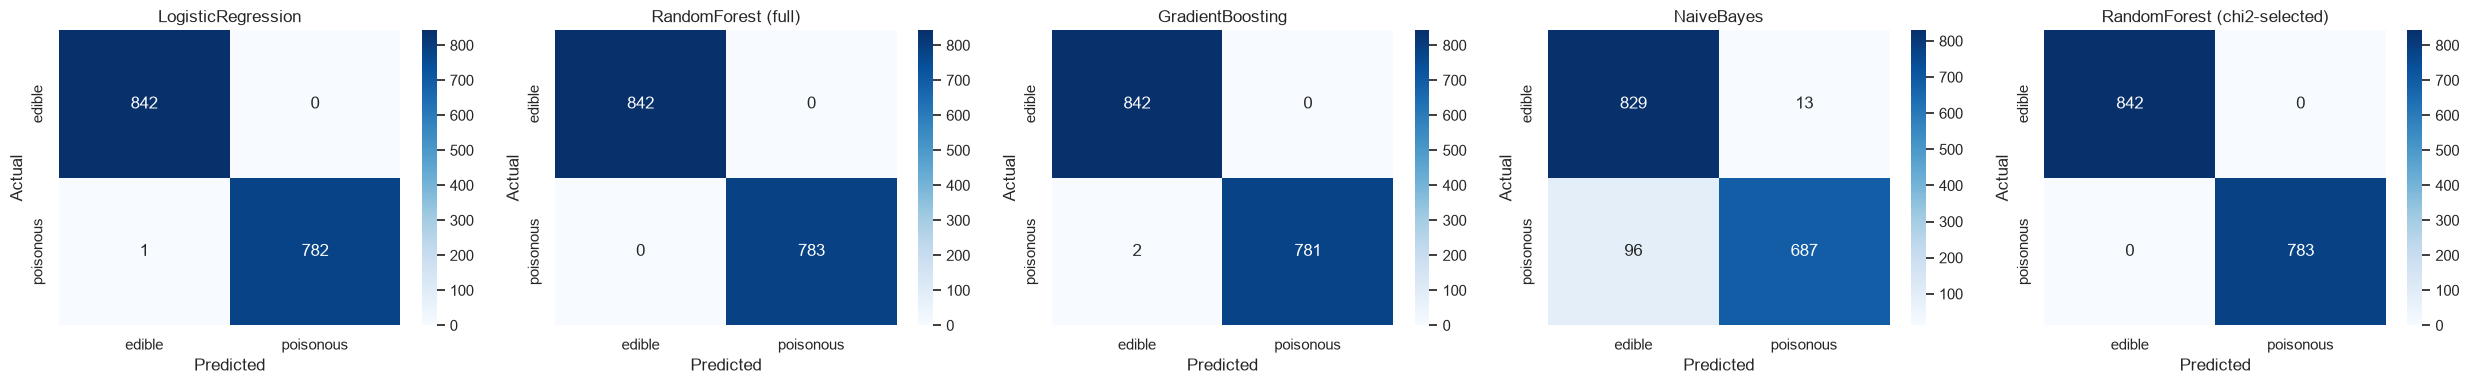

In [ ]:
fig, axes = plt.subplots(1, len(preds), figsize=(5 * len(preds), 4))
for ax, (name, (y_pred, _)) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["edible", "poisonous"], yticklabels=["edible", "poisonous"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


### 6.1 Feature importances (Random Forest)

Sanity check against the mutual-information ranking from EDA — we'd expect `odor`,
`spore-print-color`, and `gill-color` related one-hot columns near the top.


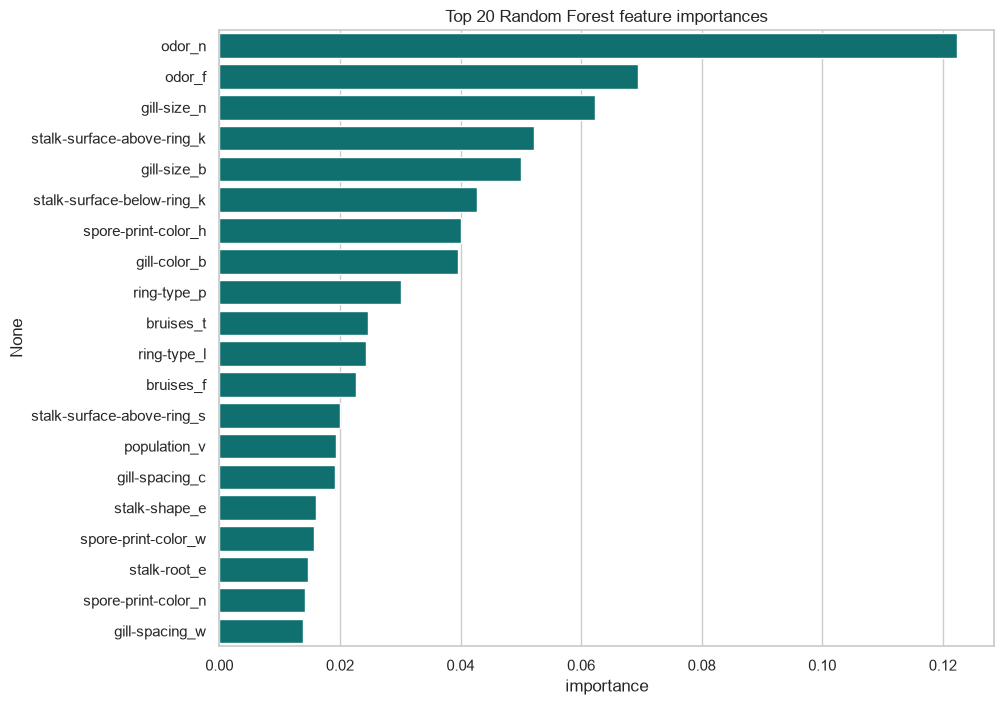

In [ ]:
importances = pd.Series(rf.feature_importances_, index=ohe_feature_names).sort_values(ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index, color="teal")
plt.title("Top 20 Random Forest feature importances")
plt.xlabel("importance")
plt.show()


### 6.2 Hyperparameter tuning (GridSearchCV)

We tune the strongest candidate (Random Forest) over key hyperparameters using 5-fold
stratified cross-validation, optimizing for F1.


In [ ]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train_ohe, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 1.0


In [ ]:
best_rf = grid_search.best_estimator_
final_metrics, y_pred_final, y_proba_final = evaluate("Tuned RandomForest", best_rf, X_test_ohe, y_test)
print(final_metrics)
print()
print(classification_report(y_test, y_pred_final, target_names=["edible", "poisonous"]))


{'model': 'Tuned RandomForest', 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'roc_auc': 1.0}

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



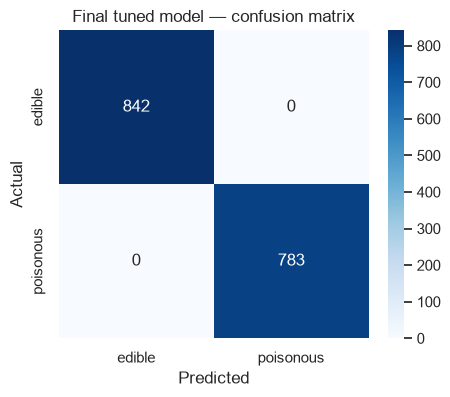

In [ ]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["edible", "poisonous"], yticklabels=["edible", "poisonous"])
plt.title("Final tuned model — confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


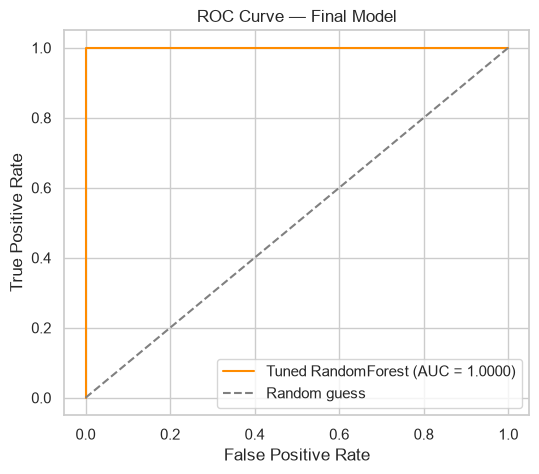

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc = roc_auc_score(y_test, y_proba_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Tuned RandomForest (AUC = {auc:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Model")
plt.legend()
plt.show()


## 7. Summary

- The dataset is fully categorical; missing `stalk-root` values (`"?"`) were recoded as an
  explicit `"unknown"` category rather than dropped, and the constant `veil-type` column
  was removed as uninformative.
- EDA (via normalized mutual information and crosstabs) showed `odor`, `spore-print-color`,
  and `gill-color` are the most discriminative single features — poisonous mushrooms are
  strongly associated with specific odor categories.
- One-hot encoding + chi-squared `SelectKBest` gave a compact, ranked feature set that
  performed on par with the full feature set for tree-based models.
- Model comparison via 5-fold CV showed Random Forest and Gradient Boosting reaching
  near-perfect F1; Random Forest was carried forward and tuned with `GridSearchCV`.
- The final tuned Random Forest achieves very high accuracy/recall on the held-out test
  set, with feature importances consistent with the EDA findings — giving confidence the
  model is learning genuine biological signal rather than noise.

**Caveat:** because this dataset separates classes almost perfectly on a handful of
features, near-100% scores here reflect the dataset's structure, not a guarantee of
real-world performance — always validate a food-safety model like this against fresh,
independently collected data before trusting it for any real decision.
